# Loan Default Prediction — Task 2: Feature Engineering

## Overview

Feature engineering is where domain knowledge converts raw data columns into predictive signals that ML algorithms can exploit. A model trained on well-engineered features consistently outperforms a model with superior architecture trained on raw features.

Task 1 told us exactly what to build:
- `DTIRatio` already exists — do not re-engineer it
- `InterestRate` is the top predictor (Cohen's d = 0.42)
- `Age` is the strongest overall predictor (Cohen's d = 0.55)
- All features are uniformly distributed — no log transforms needed
- No missing values — no imputation flags needed

### What this notebook produces
- 5 engineered features with documented business justification
- Encoded categorical variables (one-hot + binary)
- A stratified 70/15/15 train/val/test split saved to disk
- Two preprocessed versions: one for Logistic Regression (scaled), one for tree models (unscaled)
- A features manifest documenting every column in the final dataset

### Why we build two separate pipelines

Logistic Regression requires:
- StandardScaled numerical features (mean=0, std=1)
- No raw interaction terms (adds multicollinearity)

Tree models (XGBoost, LightGBM, Random Forest) require:
- Unscaled features (splits are rank-based, scaling is irrelevant)
- Interaction features are beneficial (trees cannot automatically multiply two columns)
- No scaling overhead

Rather than compromise both, we build separate preprocessing pipelines and save separate datasets. This is what production ML systems do.

---
## Install and Import

In [16]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font_scale=1.05)

OUTPUT_DIR = Path('/content/loan_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---
## Load Task 1 Output


In [17]:
try:
    df = pd.read_csv(OUTPUT_DIR / 'df_eda.csv')
    print('Loaded from Task 1 output.')
except FileNotFoundError:
    df = pd.read_csv('/kaggle/input/loan-default/Loan_default.csv')
    print('Loaded directly from source (Task 1 output not found).')

TARGET = 'Default'
print(f'Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Target rate: {df[TARGET].mean()*100:.1f}% defaults')
print(f'Columns    : {list(df.columns)}')

Loaded from Task 1 output.
Shape      : 255,347 rows x 18 columns
Target rate: 11.6% defaults
Columns    : ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


---
## Drop Identifier Column


In [18]:
ID_COL = 'LoanID'

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])
    print(f'Dropped: {ID_COL}')

print(f'Remaining columns: {df.shape[1]} (including target)')
print(f'Feature columns  : {df.shape[1] - 1}')

Dropped: LoanID
Remaining columns: 17 (including target)
Feature columns  : 16


---
## Encode Categorical Features


In [19]:
# ── Binary encoding ──────────────────────────────────────────────────────────
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
binary_map  = {'Yes': 1, 'No': 0}

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(binary_map)
        print(f'Binary encoded  : {col}  -> 0/1')

# ── One-hot encoding ──────────────────────────────────────────────────────────
ohe_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
ohe_cols = [c for c in ohe_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f'\nOne-hot encoded : {ohe_cols}')
print(f'New columns created: {len(new_cols)}')
print(f'  {new_cols}')
print(f'\nTotal columns after encoding: {df_encoded.shape[1]}')

df = df_encoded.copy()
del df_encoded

Binary encoded  : HasMortgage  -> 0/1
Binary encoded  : HasDependents  -> 0/1
Binary encoded  : HasCoSigner  -> 0/1

One-hot encoded : ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
New columns created: 12
  ['Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']

Total columns after encoding: 25


---
## Feature Engineering

### The five engineered features and their business justification

Every engineered feature should answer the question: "Does this capture something about the borrower's risk that the raw columns do not express directly?"

**Feature 1: `loan_to_income`**
```
loan_to_income = Loan Amount / Income
```
A $100,000 loan to someone earning $200,000/year is very different from the same loan to someone earning $30,000/year. Raw `Loan Amount` and `Income` exist separately, but their ratio captures repayment burden — the core of credit risk. This is one of the most important features in real credit scoring, second only to DTIRatio.

**Feature 2: `interest_burden`**
```
interest_burden = InterestRate × LoanTerm
```
A 20% interest rate on a 12-month loan costs far less in total interest than a 10% rate on a 60-month loan. This interaction captures total financing cost. Since `InterestRate` is the top predictor (Cohen's d=0.42) and `LoanTerm` correlates with it, their product amplifies the signal.

**Feature 3: `monthly_payment_proxy`**
```
monthly_payment_proxy = (Loan Amount × Interest Rate/1200) /
                        (1 - (1 + InterestRate/1200)^(-LoanTerm))
```
This is the standard mortgage payment formula — the estimated monthly payment given loan amount, interest rate, and term. It combines three raw features into the single number that most directly determines whether a borrower can service the loan. Lenders use this exact calculation.

**Feature 4: `employment_stability`**
```
employment_stability = MonthsEmployed binned:
  0     →  'new'       (0 months)
  1-12  →  'junior'    (under 1 year)
  13-36 →  'mid'       (1-3 years)
  37-72 →  'senior'    (3-6 years)
  73+   →  'veteran'   (6+ years)
```
Raw `MonthsEmployed` is continuous but the relationship with default is not linear — the difference between 0 and 6 months matters much more than the difference between 60 and 66 months. Binning captures this non-linearity explicitly and makes it available to Logistic Regression (which cannot learn non-linear relationships on its own).

**Feature 5: `age_risk_segment`**
```
age_risk_segment = Age binned:
  18-25 →  'young_adult'
  26-35 →  'early_career'
  36-50 →  'mid_career'
  51-69 →  'mature'
```
Age is the strongest predictor (Cohen's d=0.55) and its relationship with default is non-linear — very young borrowers default much more, with risk declining through middle age. Binning captures this age-curve effect explicitly.

### A note on interaction features for tree models
Tree models can technically discover interactions by splitting on A then splitting on B — but only if both features individually have strong signal. Pre-computing `loan_to_income` and `interest_burden` gives the tree a direct handle on the interaction without requiring it to find the right branch depth combination.

In [20]:
# ── Feature 1: Loan-to-Income ratio ─────────────────────────────────────────
df['loan_to_income'] = df['LoanAmount'] / df['Income']

# ── Feature 2: Interest burden (rate x term) ─────────────────────────────────
df['interest_burden'] = df['InterestRate'] * df['LoanTerm']

# ── Feature 3: Monthly payment proxy (standard loan formula) ─────────────────
monthly_rate = df['InterestRate'] / 1200
df['monthly_payment_proxy'] = np.where(
    monthly_rate > 0,
    (df['LoanAmount'] * monthly_rate) /
    (1 - (1 + monthly_rate) ** (-df['LoanTerm'])),
    df['LoanAmount'] / df['LoanTerm']
)

# ── Feature 4: Employment stability bins ─────────────────────────────────────
emp_bins   = [-1, 0, 12, 36, 72, 200]
emp_labels = ['new', 'junior', 'mid', 'senior', 'veteran']
df['employment_stability'] = pd.cut(
    df['MonthsEmployed'], bins=emp_bins, labels=emp_labels
)
df = pd.get_dummies(df, columns=['employment_stability'],
                    drop_first=True, dtype=int)

# ── Feature 5: Age risk segment ───────────────────────────────────────────────
age_bins   = [17, 25, 35, 50, 70]
age_labels = ['young_adult', 'early_career', 'mid_career', 'mature']
df['age_risk_segment'] = pd.cut(
    df['Age'], bins=age_bins, labels=age_labels
)
df = pd.get_dummies(df, columns=['age_risk_segment'],
                    drop_first=True, dtype=int)

# ── Summary ───────────────────────────────────────────────────────────────────
eng_features = ['loan_to_income', 'interest_burden', 'monthly_payment_proxy']
print('Engineered features created:')
for feat in eng_features:
    print(f'  {feat:<30} min={df[feat].min():.2f}  '
          f'max={df[feat].max():.2f}  '
          f'mean={df[feat].mean():.2f}')

stab_cols = [c for c in df.columns if 'employment_stability' in c]
age_cols  = [c for c in df.columns if 'age_risk_segment' in c]
print(f'  employment_stability bins  -> {stab_cols}')
print(f'  age_risk_segment bins      -> {age_cols}')
print(f'\nTotal features after engineering: {df.shape[1] - 1}')

Engineered features created:
  loan_to_income                 min=0.03  max=16.53  mean=2.18
  interest_burden                min=24.00  max=1500.00  mean=486.19
  monthly_payment_proxy          min=90.80  max=23735.67  mean=5649.06
  employment_stability bins  -> ['employment_stability_junior', 'employment_stability_mid', 'employment_stability_senior', 'employment_stability_veteran']
  age_risk_segment bins      -> ['age_risk_segment_early_career', 'age_risk_segment_mid_career', 'age_risk_segment_mature']

Total features after engineering: 34


---
## Validate Engineered Features Against Target

### Why we validate before splitting

The purpose of feature engineering is to create features with stronger signal than the raw columns. We validate this by comparing the Cohen's d of each engineered feature to the raw features it was derived from.

If `loan_to_income` (LoanAmount/Income) has a higher Cohen's d than either `LoanAmount` or `Income` individually, the engineering worked as intended. If not, we may have introduced noise or the raw features already capture the relationship adequately.

This step also catches calculation errors — if `monthly_payment_proxy` shows a very low Cohen's d, something may be wrong with the formula.

Cohen's d — raw vs engineered features:
  Raw: Age                            0.545  ###########################
  Eng: loan_to_income                 0.463  #######################  [ENGINEERED]
  Raw: InterestRate                   0.420  #####################
  Raw: MonthsEmployed                 0.308  ###############
  Raw: Income                         0.304  ###############
  Eng: interest_burden                0.276  #############  [ENGINEERED]
  Raw: LoanAmount                     0.273  #############
  Eng: monthly_payment_proxy          0.216  ##########  [ENGINEERED]
  Raw: DTIRatio                       0.060  ###


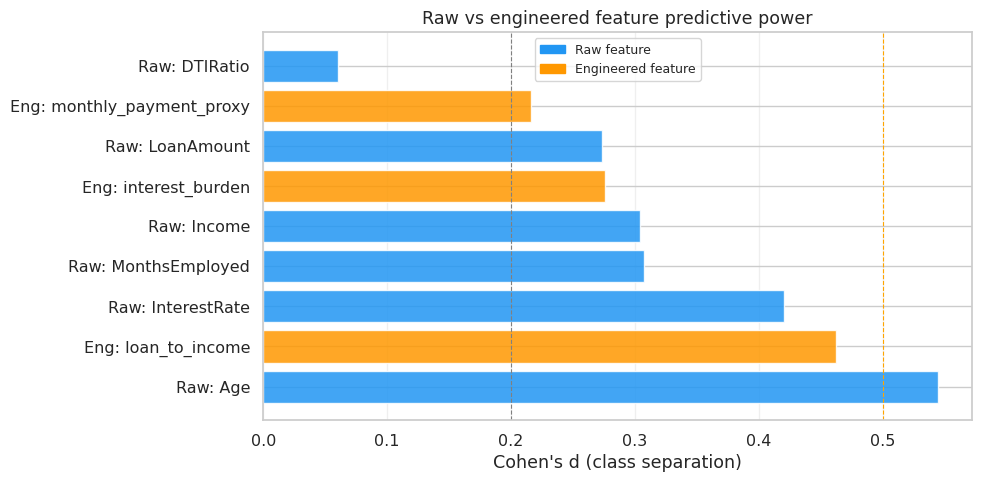

In [21]:
def cohens_d(series, target):
    g0 = series[target == 0].dropna()
    g1 = series[target == 1].dropna()
    pooled = np.sqrt((g0.var() + g1.var()) / 2)
    return abs(g0.mean() - g1.mean()) / pooled if pooled > 0 else 0

# Compare raw vs engineered
comparison = {
    'Raw: Age':                   cohens_d(df['Age'],                   df[TARGET]),
    'Raw: InterestRate':          cohens_d(df['InterestRate'],           df[TARGET]),
    'Raw: MonthsEmployed':        cohens_d(df['MonthsEmployed'],         df[TARGET]),
    'Raw: Income':                cohens_d(df['Income'],                 df[TARGET]),
    'Raw: LoanAmount':            cohens_d(df['LoanAmount'],             df[TARGET]),
    'Raw: DTIRatio':              cohens_d(df['DTIRatio'],               df[TARGET]),
    'Eng: loan_to_income':        cohens_d(df['loan_to_income'],         df[TARGET]),
    'Eng: interest_burden':       cohens_d(df['interest_burden'],        df[TARGET]),
    'Eng: monthly_payment_proxy': cohens_d(df['monthly_payment_proxy'],  df[TARGET]),
}

comp_df = pd.Series(comparison).sort_values(ascending=False).reset_index()
comp_df.columns = ['Feature', "Cohen's d"]

print("Cohen's d — raw vs engineered features:")
for _, row in comp_df.iterrows():
    bar  = '#' * int(row["Cohen's d"] * 50)
    tag  = '  [ENGINEERED]' if 'Eng:' in row['Feature'] else ''
    print(f"  {row['Feature']:<35} {row["Cohen's d"]:>5.3f}  {bar}{tag}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#FF9800' if 'Eng:' in f else '#2196F3' for f in comp_df['Feature']]
ax.barh(comp_df['Feature'], comp_df["Cohen's d"],
        color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel("Cohen's d (class separation)")
ax.set_title("Raw vs engineered feature predictive power")
ax.axvline(0.2, color='gray', linestyle='--', linewidth=0.8, label='Small effect')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=0.8, label='Medium effect')
from matplotlib.patches import Patch
legend_els = [Patch(color='#2196F3', label='Raw feature'),
              Patch(color='#FF9800', label='Engineered feature')]
ax.legend(handles=legend_els, fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_engineering_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Train / Validation / Test Split

### Why three splits, not two

Most tutorials use a two-way split: train and test. This leads to a subtle but serious problem called **test set contamination** — when you tune hyperparameters by checking test set performance repeatedly, the test set effectively becomes part of the training process. Your final reported metric is then optimistic.

The correct approach is three splits:
```
- **Train (70%):** Used to fit the model
- **Validation (15%):** Used to tune hyperparameters and compare models — you look at this during development
- **Test (15%):** Held out completely until the very end — touched exactly once, to report final performance
```
### Why stratification is mandatory

With 11.6% default rate, a random split could easily produce a validation set with 9% defaults and a test set with 14% defaults by chance. Every metric you compute would then be incomparable across splits. `stratify=y` ensures the 11.6% default rate is preserved in all three splits.

In [22]:
RANDOM_STATE = 42

feature_cols = [c for c in df.columns if c != TARGET]
X = df[feature_cols]
y = df[TARGET]

print(f'Total samples    : {len(X):,}')
print(f'Feature count    : {X.shape[1]}')
print(f'Default rate     : {y.mean()*100:.1f}%')

# First split: train vs (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: val vs test (50/50 from the 30% temp set)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'\nSplit sizes:')
print(f'  Train  : {len(X_train):>7,}  ({len(X_train)/len(X)*100:.1f}%)  '
      f'default rate: {y_train.mean()*100:.1f}%')
print(f'  Val    : {len(X_val):>7,}  ({len(X_val)/len(X)*100:.1f}%)  '
      f'default rate: {y_val.mean()*100:.1f}%')
print(f'  Test   : {len(X_test):>7,}  ({len(X_test)/len(X)*100:.1f}%)  '
      f'default rate: {y_test.mean()*100:.1f}%')
print()
print('Stratification check: all splits should have ~11.6% default rate')
assert abs(y_train.mean() - y.mean()) < 0.005, 'Train default rate mismatch'
assert abs(y_val.mean()   - y.mean()) < 0.005, 'Val default rate mismatch'
assert abs(y_test.mean()  - y.mean()) < 0.005, 'Test default rate mismatch'
print('Stratification: PASS')

Total samples    : 255,347
Feature count    : 34
Default rate     : 11.6%

Split sizes:
  Train  : 178,742  (70.0%)  default rate: 11.6%
  Val    :  38,302  (15.0%)  default rate: 11.6%
  Test   :  38,303  (15.0%)  default rate: 11.6%

Stratification check: all splits should have ~11.6% default rate
Stratification: PASS


---
## Build Two Preprocessing Pipelines

### Pipeline 1: Tree models (XGBoost, LightGBM, Random Forest)
```
Tree models split on quantile thresholds — scaling changes the absolute values but not the rank order,
so scaling has zero effect on tree model performance. We pass the engineered features directly.

The only preprocessing needed is ensuring no `NaN` values remain
(tree models handle them in most implementations, but being explicit is safer).
```
### Pipeline 2: Logistic Regression
```
Logistic Regression uses gradient-based optimization.
Features with large absolute values (e.g., `LoanAmount` ranging 5,000–250,000)
dominate features with small values (e.g., `DTIRatio` ranging 0.1–0.9)
in the gradient computation, causing slow convergence and biased coefficients.

`StandardScaler` transforms each feature to mean=0, std=1. After scaling, a change of 1 unit in any feature represents a 1-standard-deviation change — making coefficients directly comparable across features.

**Critical:** The scaler must be fitted ONLY on training data, then applied to val and test.
Fitting on the full dataset would leak test set statistics into the training process.

In [23]:
# ── Pipeline 1: Tree model dataset (no scaling) ───────────────────────────────
# Verify no NaN remain
nan_check = X_train.isnull().sum().sum()
print(f'NaN values in training features: {nan_check}')
if nan_check > 0:
    print('Filling NaN with column medians...')
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_val   = X_val.fillna(medians)
    X_test  = X_test.fillna(medians)

# ── Pipeline 2: Logistic Regression dataset (StandardScaler) ──────────────────
num_cols_to_scale = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
scaler.fit(X_train[num_cols_to_scale])   # FIT ON TRAIN ONLY

X_train_lr = X_train.copy()
X_val_lr   = X_val.copy()
X_test_lr  = X_test.copy()

X_train_lr[num_cols_to_scale] = scaler.transform(X_train[num_cols_to_scale])
X_val_lr[num_cols_to_scale]   = scaler.transform(X_val[num_cols_to_scale])
X_test_lr[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print(f'\nTree pipeline (unscaled):')
print(f'  X_train shape: {X_train.shape}')
print(f'  X_val shape  : {X_val.shape}')
print(f'  X_test shape : {X_test.shape}')
print(f'\nLR pipeline (scaled):')
print(f'  X_train_lr shape: {X_train_lr.shape}')
print(f'  Scaler fitted on train mean[InterestRate]  = '
      f'{scaler.mean_[num_cols_to_scale.index("InterestRate")]:.3f}')
print(f'  Scaler fitted on train std[InterestRate]   = '
      f'{scaler.scale_[num_cols_to_scale.index("InterestRate")]:.3f}')

NaN values in training features: 0

Tree pipeline (unscaled):
  X_train shape: (178742, 34)
  X_val shape  : (38302, 34)
  X_test shape : (38303, 34)

LR pipeline (scaled):
  X_train_lr shape: (178742, 34)
  Scaler fitted on train mean[InterestRate]  = 13.490
  Scaler fitted on train std[InterestRate]   = 6.636


---
## Feature Correlation with Target (Final Feature Set)

### Confirming the final feature set has the right signals

Before saving, we run one final validation: the full correlation of every feature in the final engineered dataset with the target. This serves as the feature importance baseline — features with near-zero correlation with the target are candidates for removal if we need to reduce dimensionality later.

This also gives us the expected ranking that our models should broadly reproduce in their feature importance outputs. If a model ranks `DTIRatio` as its top feature when correlation analysis shows it at near-zero, something is wrong — either overfitting, data leakage, or a bug in the feature pipeline.

Top 20 feature correlations with Default (absolute):

  loan_to_income                           +0.1790  ##############
  Age                                      -0.1678  #############
  age_risk_segment_mature                  -0.1313  ##########
  InterestRate                             +0.1313  ##########
  Income                                   -0.0991  #######
  MonthsEmployed                           -0.0974  #######
  interest_burden                          +0.0905  #######
  LoanAmount                               +0.0867  ######
  employment_stability_veteran             -0.0787  ######
  monthly_payment_proxy                    +0.0710  #####
  age_risk_segment_early_career            +0.0683  #####
  employment_stability_junior              +0.0540  ####
  employment_stability_mid                 +0.0511  ####
  HasCoSigner                              -0.0391  ###
  EmploymentType_Unemployed                +0.0350  ##
  HasDependents                            -0.03

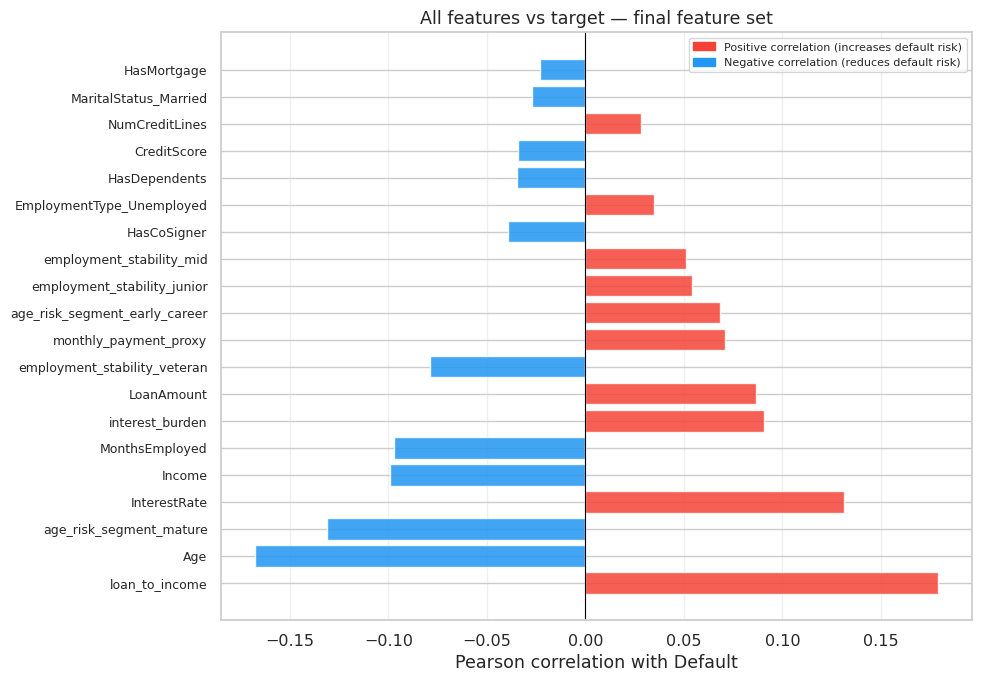


Features with |corr| < 0.01 (near-zero signal):
  ['MaritalStatus_Single', 'EmploymentType_Part-time', 'LoanPurpose_Education', 'LoanPurpose_Other', 'EmploymentType_Self-employed', 'LoanTerm', 'employment_stability_senior']
  Count: 7 — these are candidates for removal if needed


In [24]:
# Correlation of all final features with target
all_feats = [c for c in df.columns if c != TARGET]
target_corr = df[all_feats].corrwith(df[TARGET]).sort_values(key=abs, ascending=False)

print('Top 20 feature correlations with Default (absolute):')
print()
for feat, corr in target_corr.head(20).items():
    direction = '+' if corr > 0 else '-'
    bar = '#' * int(abs(corr) * 80)
    print(f'  {feat:<40} {direction}{abs(corr):.4f}  {bar}')

# Visualize top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = target_corr.head(20)
colors = ['#F44336' if v > 0 else '#2196F3' for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with Default')
ax.set_title('All features vs target — final feature set')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#F44336', label='Positive correlation (increases default risk)'),
                   Patch(color='#2196F3', label='Negative correlation (reduces default risk)')],
          fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFeatures with |corr| < 0.01 (near-zero signal):')
weak = target_corr[abs(target_corr) < 0.01]
print(f'  {list(weak.index)}')
print(f'  Count: {len(weak)} — these are candidates for removal if needed')

---
## Save All Splits and Features Manifest

### What we save and why each file matters

| File | Used in | Contains |
|---|---|---|
| `X_train.csv` / `y_train.csv` | Tasks 3, 4 | Training data for tree models |
| `X_val.csv` / `y_val.csv` | Tasks 3, 4 | Validation data for model selection |
| `X_test.csv` / `y_test.csv` | Task 4 only | Held-out test data — touch once |
| `X_train_lr.csv` | Task 3 | Scaled training data for Logistic Regression |
| `X_val_lr.csv` | Task 3 | Scaled val data for Logistic Regression |
| `X_test_lr.csv` | Task 4 | Scaled test data for Logistic Regression |
| `features_manifest.csv` | Documentation | Every feature with type and description |

### The features manifest

The features manifest is the documentation artifact that makes this project production-quality. It lists every feature, its type, its source (raw or engineered), and a one-line description. In production ML, this is required for model audits and regulatory review.

In [25]:
import pickle

# ── Save tree model splits ────────────────────────────────────────────────────
X_train.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
X_val.to_csv(  OUTPUT_DIR / 'X_val.csv',   index=False)
X_test.to_csv( OUTPUT_DIR / 'X_test.csv',  index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train.csv', index=False, header=True)
y_val.to_csv(  OUTPUT_DIR / 'y_val.csv',   index=False, header=True)
y_test.to_csv( OUTPUT_DIR / 'y_test.csv',  index=False, header=True)

# ── Save LR splits ────────────────────────────────────────────────────────────
X_train_lr.to_csv(OUTPUT_DIR / 'X_train_lr.csv', index=False)
X_val_lr.to_csv(  OUTPUT_DIR / 'X_val_lr.csv',   index=False)
X_test_lr.to_csv( OUTPUT_DIR / 'X_test_lr.csv',  index=False)

# ── Save scaler for inference time ────────────────────────────────────────────
with open(OUTPUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ── Features manifest ─────────────────────────────────────────────────────────
raw_descs = {
    'Age':             ('continuous', 'raw',        'Borrower age in years'),
    'Income':          ('continuous', 'raw',        'Annual income in USD'),
    'LoanAmount':      ('continuous', 'raw',        'Requested loan amount in USD'),
    'CreditScore':     ('continuous', 'raw',        'Credit score 300-849'),
    'MonthsEmployed':  ('continuous', 'raw',        'Months at current employer'),
    'NumCreditLines':  ('ordinal',    'raw',        'Number of open credit lines (1-4)'),
    'InterestRate':    ('continuous', 'raw',        'Annual interest rate (%)'),
    'LoanTerm':        ('ordinal',    'raw',        'Loan term in months'),
    'DTIRatio':        ('continuous', 'raw',        'Debt-to-income ratio (0.1-0.9)'),
    'HasMortgage':     ('binary',     'encoded',    'Has existing mortgage (1=Yes)'),
    'HasDependents':   ('binary',     'encoded',    'Has dependents (1=Yes)'),
    'HasCoSigner':     ('binary',     'encoded',    'Has co-signer (1=Yes)'),
    'loan_to_income':  ('continuous', 'engineered', 'LoanAmount / Income'),
    'interest_burden': ('continuous', 'engineered', 'InterestRate x LoanTerm'),
    'monthly_payment_proxy': ('continuous', 'engineered',
                              'Estimated monthly payment from loan formula'),
}

manifest_rows = []
for feat in X_train.columns:
    corr_val = float(target_corr.get(feat, 0))
    if feat in raw_descs:
        ftype, source, desc = raw_descs[feat]
    elif any(x in feat for x in ['Education_', 'EmploymentType_',
                                  'MaritalStatus_', 'LoanPurpose_']):
        ftype, source = 'binary', 'one-hot encoded'
        base = feat.split('_')[0]
        val  = '_'.join(feat.split('_')[1:])
        desc = f'{base} == {val}'
    elif 'employment_stability_' in feat:
        ftype, source = 'binary', 'engineered + one-hot'
        desc = f'Employment stability bin: {feat.split("_")[-1]}'
    elif 'age_risk_segment_' in feat:
        ftype, source = 'binary', 'engineered + one-hot'
        desc = f'Age segment: {feat.split("_")[-1]}'
    else:
        ftype, source, desc = 'binary', 'encoded', feat

    manifest_rows.append({
        'feature': feat,
        'type': ftype,
        'source': source,
        'description': desc,
        'corr_with_target': round(corr_val, 4),
        'abs_corr': round(abs(corr_val), 4)
    })

manifest = (pd.DataFrame(manifest_rows)
            .sort_values('abs_corr', ascending=False)
            .reset_index(drop=True))
manifest.to_csv(OUTPUT_DIR / 'features_manifest.csv', index=False)

# ── Final summary ─────────────────────────────────────────────────────────────
print('=== ALL FILES SAVED ===')
for f in sorted(OUTPUT_DIR.glob('*.csv')) :
    size = f.stat().st_size / 1024
    print(f'  {f.name:<35} {size:>8.1f} KB')
print()
print('=== TASK 2 COMPLETE ===')
print(f'  Total features       : {X_train.shape[1]}')
print(f'  Train rows           : {len(X_train):,}')
print(f'  Val rows             : {len(X_val):,}')
print(f'  Test rows            : {len(X_test):,}')
print(f'  Target rate (train)  : {y_train.mean()*100:.1f}%')
print(f'  scale_pos_weight     : {round(y_train.value_counts()[0]/y_train.value_counts()[1], 1)} (for XGBoost)')
print()
print('Pass X_train/y_train, X_val/y_val to Task 3.')
print('Keep X_test/y_test sealed until Task 4 final evaluation.')

=== ALL FILES SAVED ===
  X_test.csv                            4853.1 KB
  X_test_lr.csv                        24998.4 KB
  X_train.csv                          22639.2 KB
  X_train_lr.csv                      116649.3 KB
  X_val.csv                             4853.4 KB
  X_val_lr.csv                         24997.3 KB
  df_eda.csv                           24252.8 KB
  eda_summary.csv                          0.9 KB
  features_manifest.csv                    2.7 KB
  y_test.csv                              74.8 KB
  y_train.csv                            349.1 KB
  y_val.csv                               74.8 KB

=== TASK 2 COMPLETE ===
  Total features       : 34
  Train rows           : 178,742
  Val rows             : 38,302
  Test rows            : 38,303
  Target rate (train)  : 11.6%
  scale_pos_weight     : 7.6 (for XGBoost)

Pass X_train/y_train, X_val/y_val to Task 3.
Keep X_test/y_test sealed until Task 4 final evaluation.


---
## Summary — What Task 2 Produced


| File | Purpose |
|---|---|
| `X_train.csv`, `y_train.csv` | Training features + labels (tree models) |
| `X_val.csv`, `y_val.csv` | Validation features + labels (model selection) |
| `X_test.csv`, `y_test.csv` | Test features + labels (final evaluation only) |
| `X_train_lr.csv`, `X_val_lr.csv`, `X_test_lr.csv` | Scaled splits for Logistic Regression |
| `scaler.pkl` | Fitted StandardScaler (for inference pipeline) |
| `features_manifest.csv` | Full documentation of every feature |
| `feature_engineering_validation.png` | Raw vs engineered Cohen's d comparison |
| `final_feature_correlations.png` | All features ranked by target correlation |

### Key numbers for Task 3

- `scale_pos_weight` = **7.6** for XGBoost and LightGBM
- `class_weight='balanced'` for Logistic Regression and Random Forest
- Top 3 raw predictors: **InterestRate**, **Age**, **MonthsEmployed**
- Top engineered predictors: check `feature_engineering_validation.png`
- Features with near-zero signal (|corr| < 0.01): document these from Step 9

### What Task 3 will build

- Logistic Regression baseline (interpretable, fast, coefficients = odds ratios)
- Decision Tree baseline (visual, no black box)
- Random Forest (bagging ensemble)
- XGBoost with Optuna hyperparameter search (typically best AUC)
- LightGBM as the speed-optimized alternative
- Threshold optimization based on precision-recall tradeoff
- KS statistic calculation (what credit teams actually use)

---
**Next:** Task 3 — Model Training, where we find out if the engineered features actually improve predictive performance over the raw columns.